# Test Data Downloader Template

In [1]:
from pathlib import Path
import sys

repo_root = Path('.').resolve()
for _ in range(5):
    if (repo_root / 'src').is_dir():
        repo_root = f"{repo_root}/src"
        break
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

print(f"Repo root: {repo_root}")

import rasterio
from rasterio.windows import Window
from datetime import datetime
from osgeo import gdal
from shared_utils import s3utils
from shared_utils.plotting import preview_cogs
from satellogic.satellogic_v2 import retrieve_satellogic_resources
from umbra.umbra_v2 import retrieve_umbra_resources
from capella.capella_v2 import retrieve_capella_resources
#from skysat.skysat_v2 import retrieve_skysat_resources

Repo root: /home/jovyan/disasters-product-algorithms/src


In [2]:
def download_test_data(bucket, key, save_location, filename):
    session = s3utils._read_session()
    s3_client = session.client('s3')
    outpath = f"{save_location}/{filename}"
    s3_client.download_file(bucket, key, outpath)

In [3]:
def create_segment_file(input_filename, output_filename):
    with rasterio.open(input_filename) as src:
        width = src.width
        height = src.height
        window = Window(int(width/2)-50, int(height/2)-50, 100, 100)
    
        data = src.read(window=window)
    
        meta = src.meta.copy()
        tags = src.tags()

        transform = rasterio.windows.transform(window, src.transform)
        meta.update({"height": 100, "width": 100, "transform": transform})
    
        with rasterio.open(output_filename, "w", **meta) as dst:
            dst.update_tags(**tags)
            dst.write(data)

### Downloading and clipping data

The following cells complete the same three steps for each of the three vendors included here:
1) Gather a list of all applicable files
2) Loop over the list of files, dowloading each one
3) Convert each downloaded file into a 100x100px sample taken from near the middle

Steps 2 and 3 are visualized along the way to ensure the validity of the data.

In [4]:
satellogic_metadata, satellogic_tifs = retrieve_satellogic_resources(datetime(2026, 1, 1), "L1D", "csda-data-vendor-satellogic", "disasters")

Selected Satellogic folder: 20251231_122643_857_SN28_L1D_SR_MS
Metadata files found: 14
TIF files found: 3
   disasters/20251231_122643_857_SN28_L1D_SR_MS/rasters/20251231_122643_857_SN28_L1D_SR_MS_CLOUD_0.tif
   disasters/20251231_122643_857_SN28_L1D_SR_MS/rasters/20251231_122643_857_SN28_L1D_SR_MS_TOA_0.tif
   disasters/20251231_122643_857_SN28_L1D_SR_MS/rasters/20251231_122643_857_SN28_L1D_SR_MS_VISUAL_0.tif


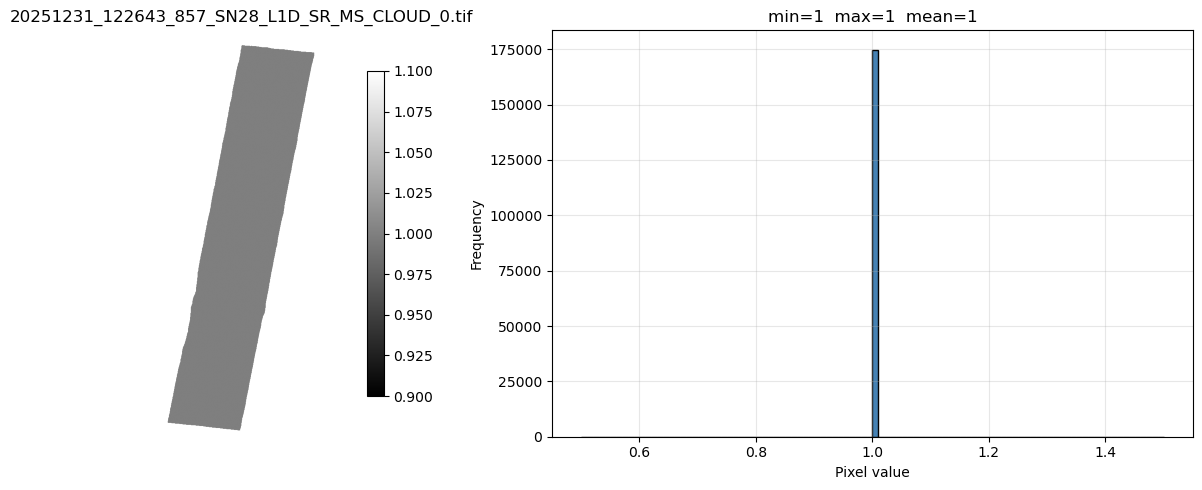

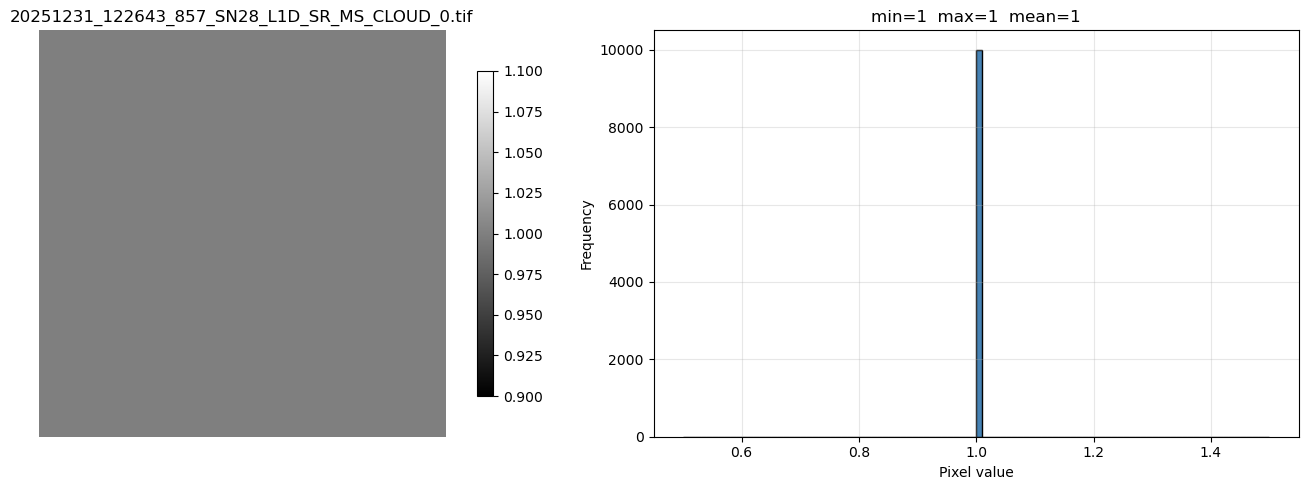

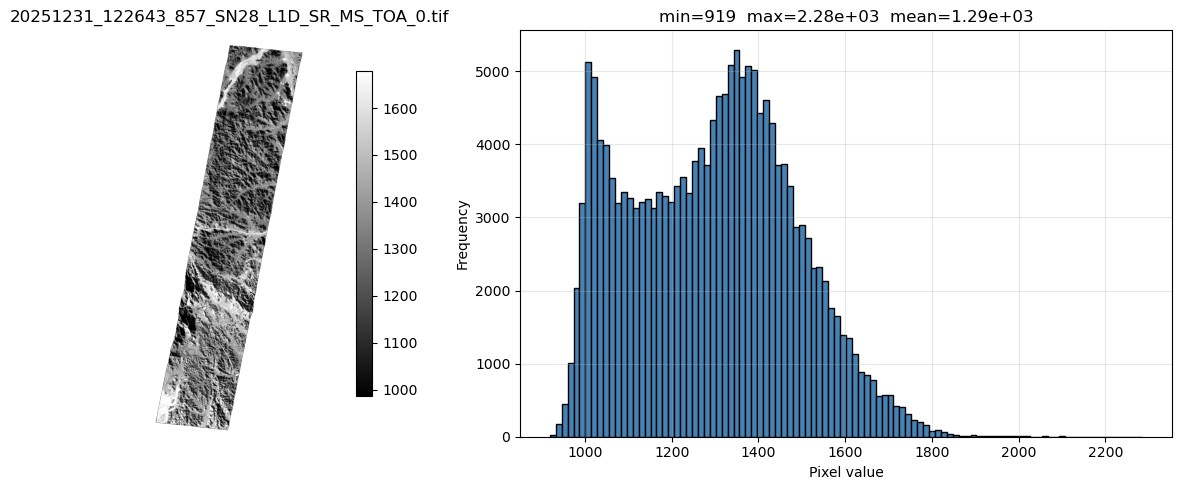

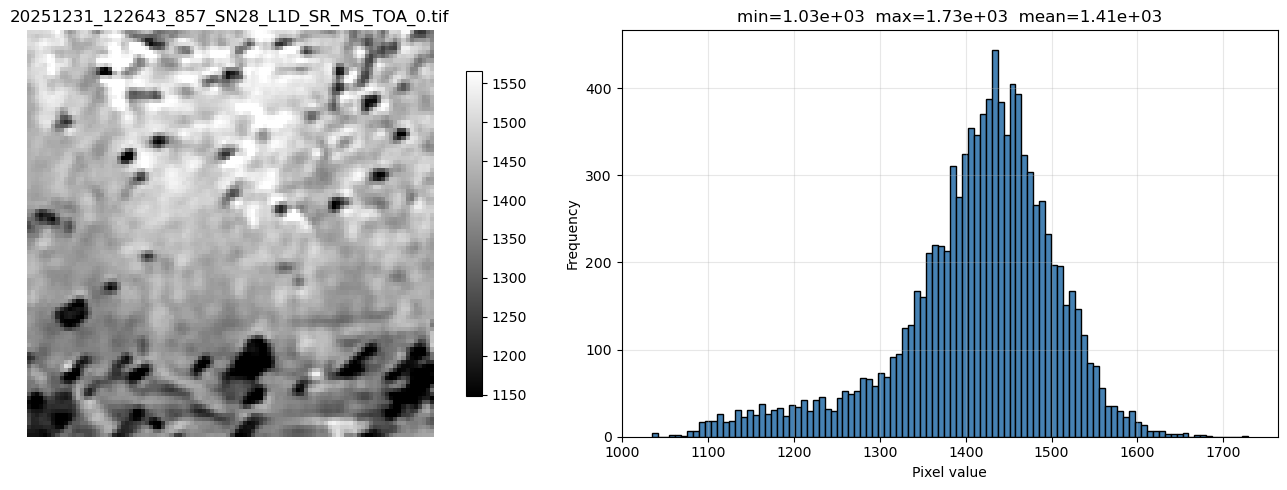

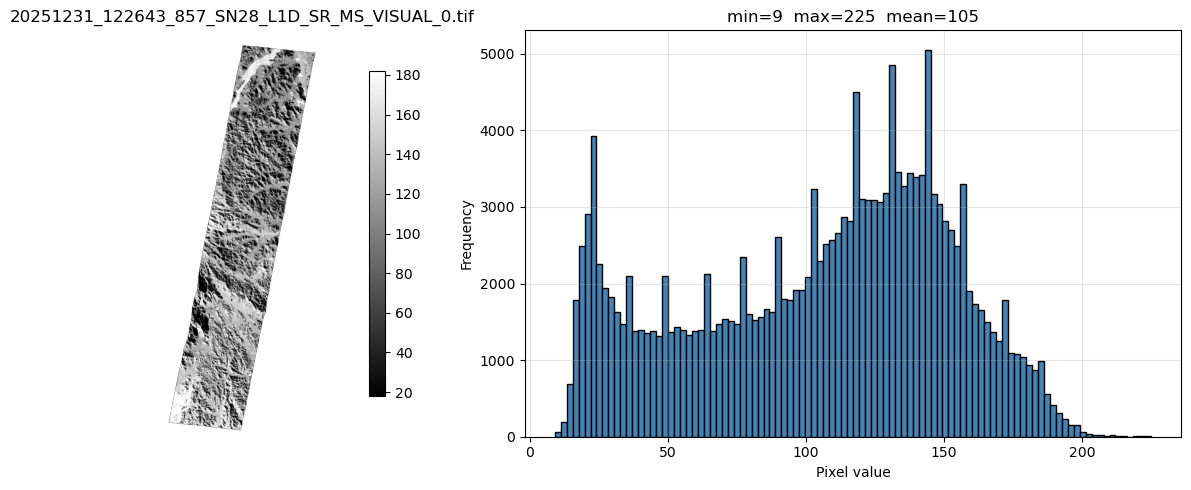

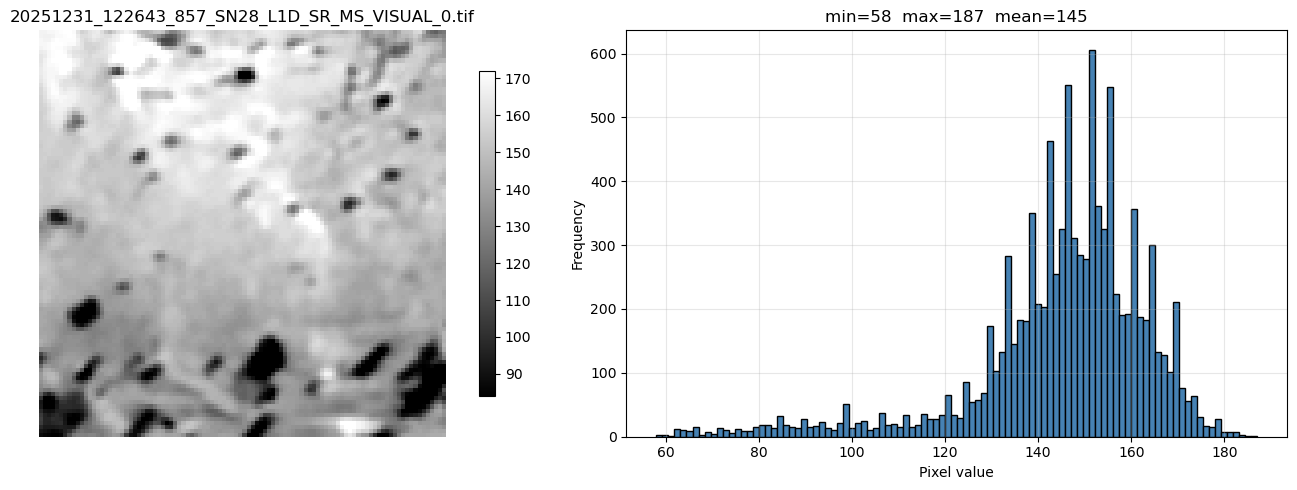

In [5]:
for file in satellogic_tifs:
    download_test_data("csda-data-vendor-satellogic", "/".join(file.split("/")[3:]), "./satellogic", file.split("/")[-1])
    preview_cogs([f"./satellogic/{file.split('/')[-1]}"], sample_n=4)
    create_segment_file(f"./satellogic/{file.split('/')[-1]}", f"./satellogic/{file.split('/')[-1]}")
    preview_cogs([f"./satellogic/{file.split('/')[-1]}"], sample_n=4)

In [6]:
for file in satellogic_metadata:
    download_test_data("csda-data-vendor-satellogic", "/".join(file.split("/")[3:]), "./satellogic", file.split("/")[-1])

In [7]:
umbra_tifs = retrieve_umbra_resources(datetime(2026, 1, 1), "csda-data-vendor-umbra", "disasters")

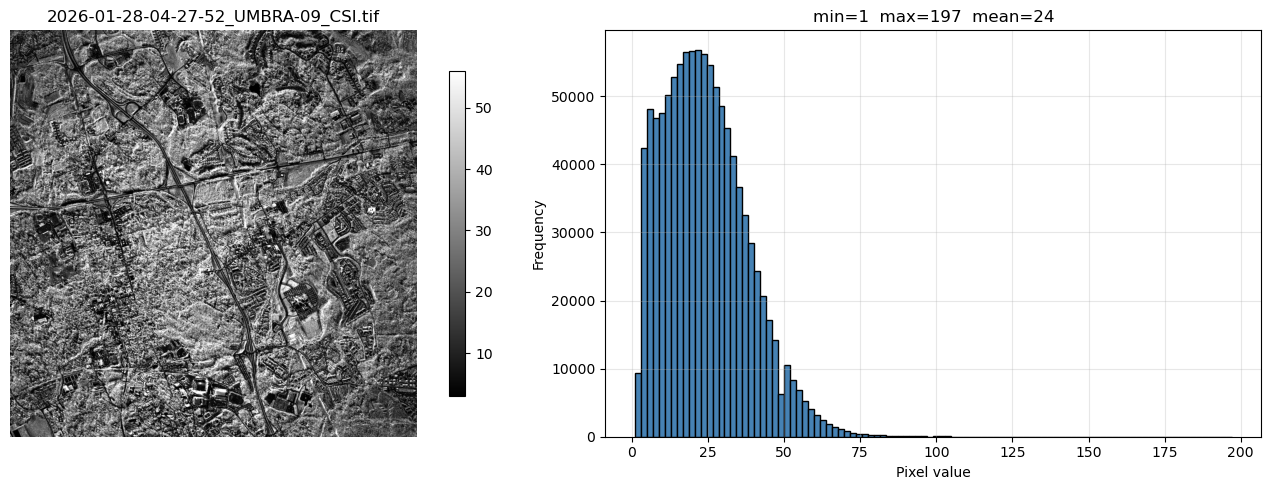

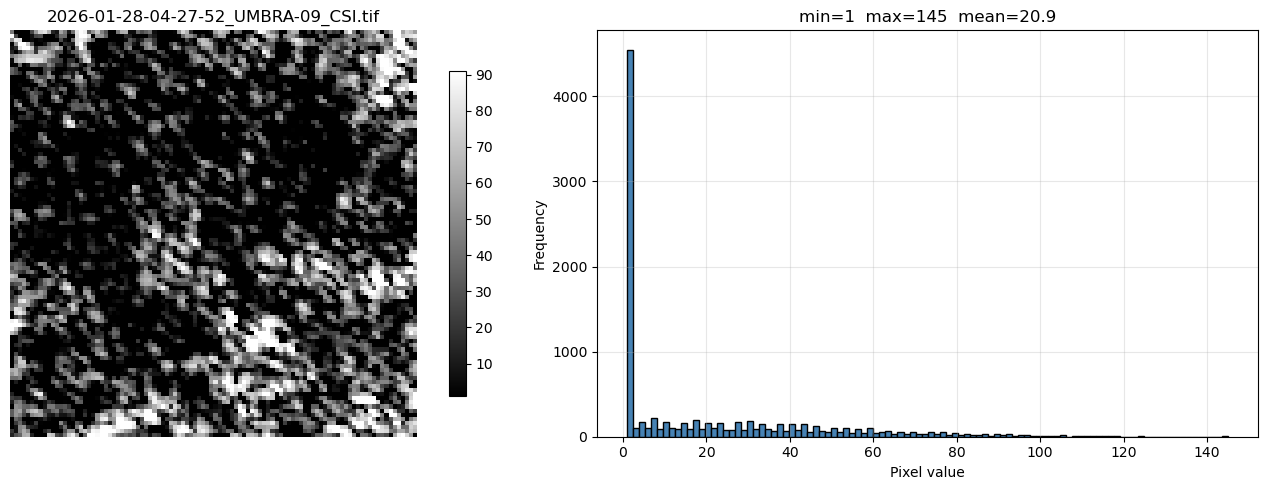

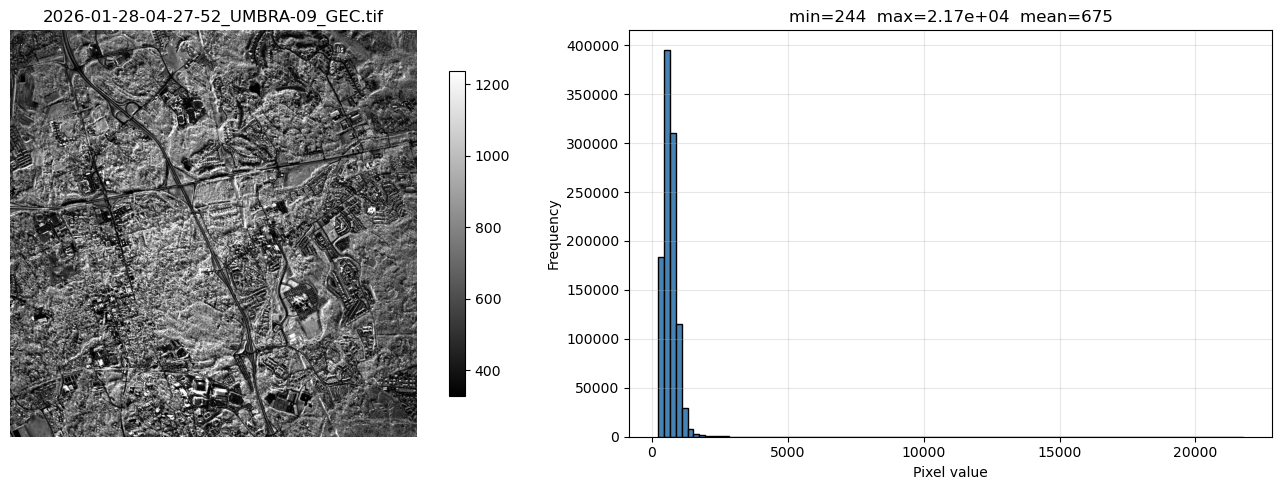

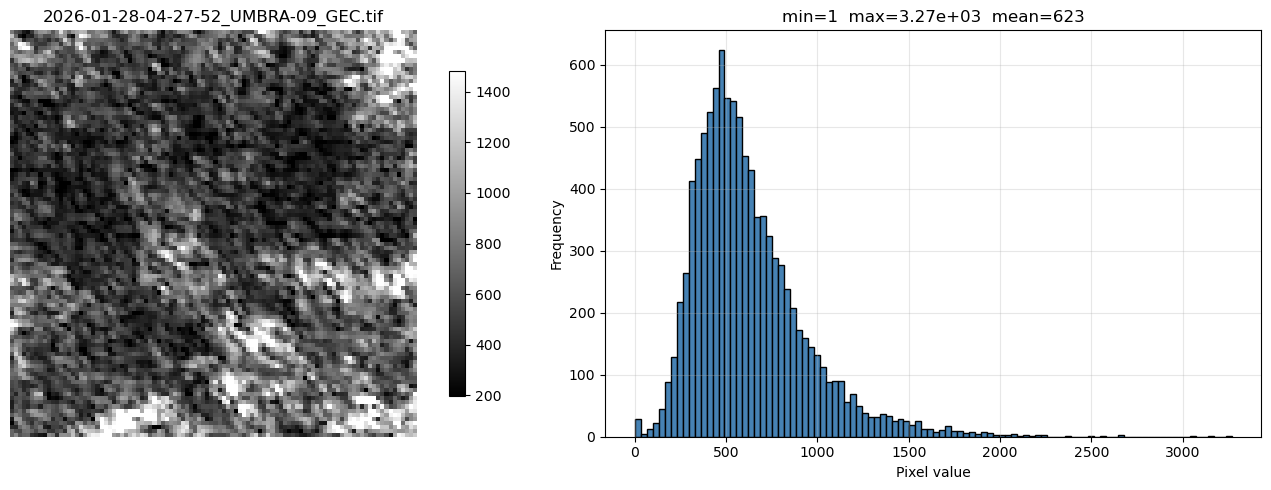

In [8]:
for file in umbra_tifs:
    download_test_data("csda-data-vendor-umbra", "/".join(file.split("/")[3:]), "./umbra", file.split("/")[-1])
    preview_cogs([f"./umbra/{file.split('/')[-1]}"], sample_n=4)
    create_segment_file(f"./umbra/{file.split('/')[-1]}", f"./umbra/{file.split('/')[-1]}")
    preview_cogs([f"./umbra/{file.split('/')[-1]}"], sample_n=4)

In [9]:
capella_tifs = retrieve_capella_resources(datetime(2026, 1, 1), "csdap-capellaspace-delivery", "disasters")

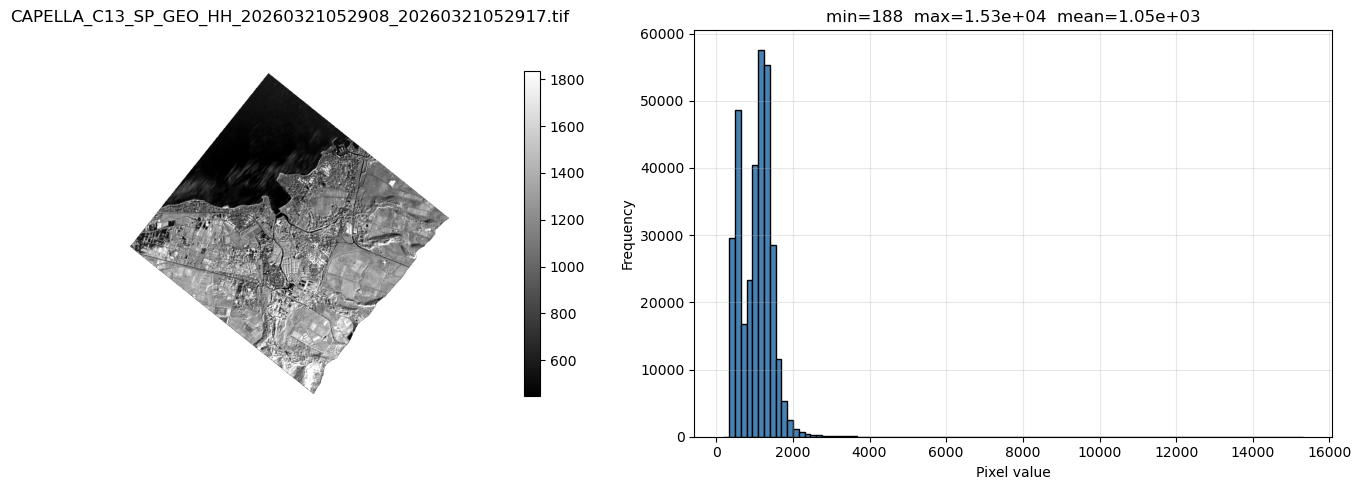

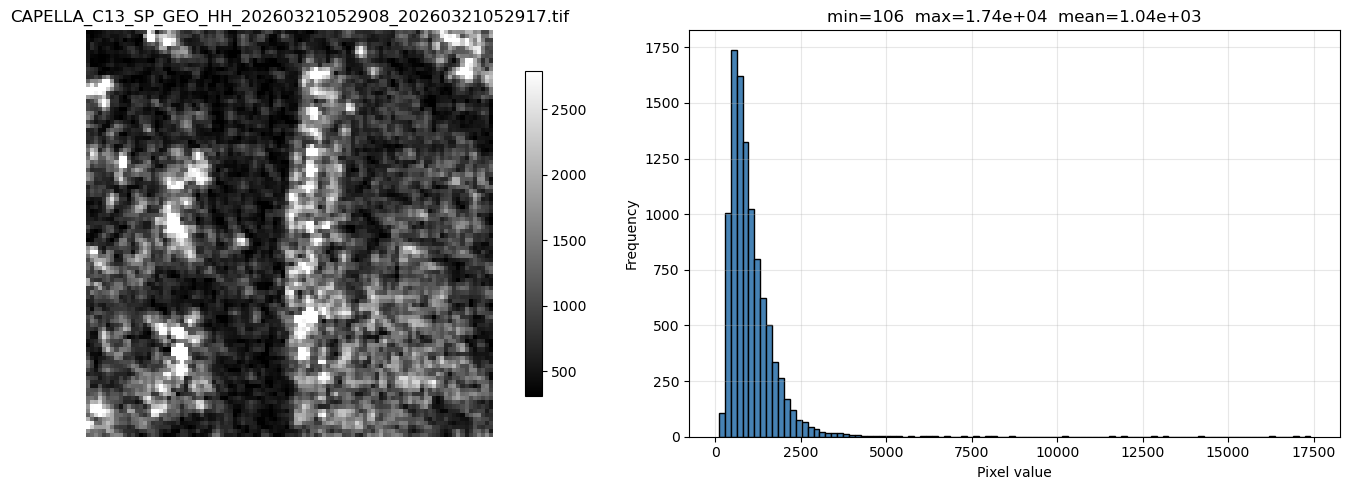

/home/jovyan/disasters-product-algorithms/src/shared_utils/plotting.py:48: ComplexWarning: Casting complex values to real discards the imaginary part
  ).astype(float)


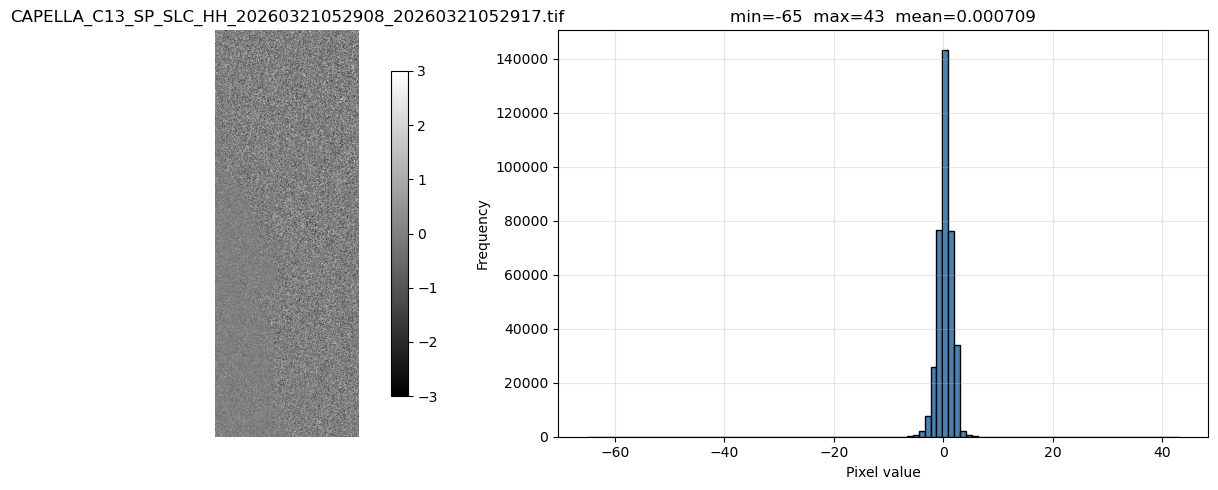

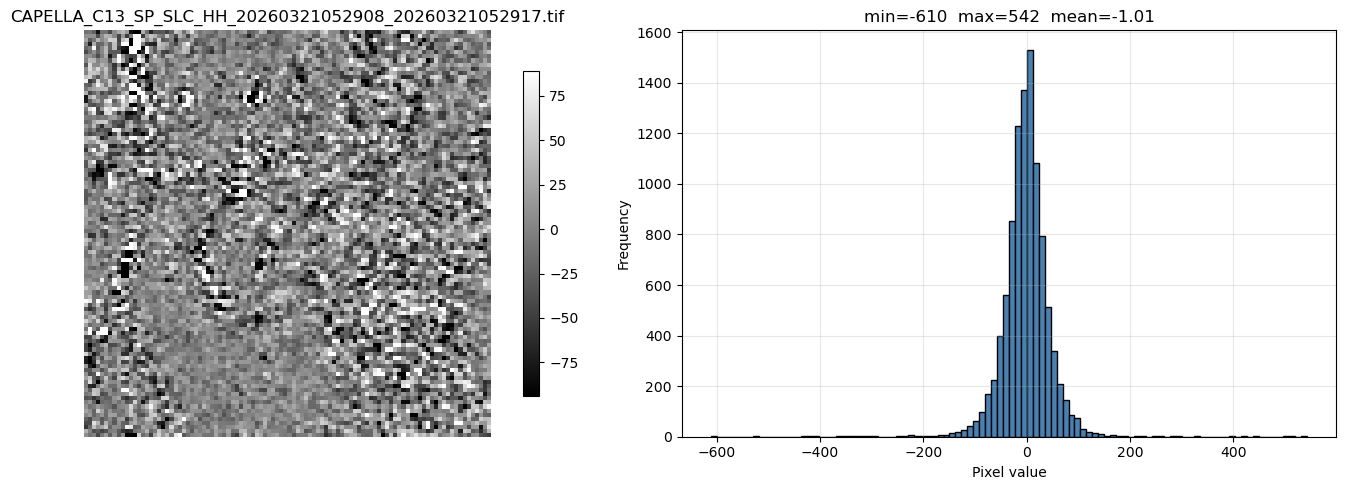

In [10]:
for file in capella_tifs:
    download_test_data("csdap-capellaspace-delivery", "/".join(file.split("/")[3:]), "./capella", file.split("/")[-1])
    preview_cogs([f"./capella/{file.split('/')[-1]}"], sample_n=4)
    create_segment_file(f"./capella/{file.split('/')[-1]}", f"./capella/{file.split('/')[-1]}")
    preview_cogs([f"./capella/{file.split('/')[-1]}"], sample_n=4)

### Example Usage (Umbra SigmaCalib)
Since all functions based on downloaded s3 data expect it to be found in `/tmp/s3_temp/`, we should copy this test data there to make sure it passes the check, then clear the temp directory afterwards.

I ran a %%timeit on the cell below, and it took only 3.02ms to run, so these smaller domain images should be *much* nicer for testing purposes.

In [18]:
import shutil
from glob import glob
from umbra.umbra_v2 import sigmaCalib
import os

def temp_placement(source_files: str) -> list[str]:

    copy_filelist = glob(source_files)
    temp_filelist = []
    for file in copy_filelist:
        if not os.path.exists("/tmp/s3_temp/"):
            os.mkdir("/tmp/s3_temp/")
        shutil.copy(file, f"/tmp/s3_temp/{file.split("/")[-1]}")
        temp_filelist.append(f"/tmp/s3_temp/{file.split("/")[-1]}")

    return temp_filelist

files = temp_placement("./umbra/*.tif") # "/home/jovyan/disasters-product-algorithms/tests/vendor-test-data/umbra/*.tif" is the absolute filepath, so you can run it from anywhere

sigmaCalib(files)

GEC file found, proceeding
Generating Sigma Naught

	* Opening GEC File
3267 1
{'COLLECT_ID': 'f398f657-c216-492b-8973-d3d9956ad2b1', 'DN_TO_BETA': '0.0006803314054672868', 'DN_TO_GAMMA': '0.0005437585067769974', 'DN_TO_RCS': '0.00019257371166474564', 'DN_TO_SIGMA': '0.00048253264059943237', 'PROCESSOR': '4.32.0', 'AREA_OR_POINT': 'Area'}
0.00048253264059943237
<class 'str'>
3.953516614203755 -66.32946607530499
Generation completed, file saved to /tmp/s3_temp/202601_Umbra-09_sigma02026-01-28T04:27:52Z.tif


'/tmp/s3_temp/202601_Umbra-09_sigma02026-01-28T04:27:52Z.tif'

In [19]:
s3utils.remove_s3_temp()